In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

In [3]:
# total number of color bins to use for visualization
vis_bins = 20

nice_text = {'C':'Cell Measured with Bins Starting at the Center of the Cell',
             'CCN':'Cell Measured with Bins Starting at the Center of the Nucleus',
             'CEN':'Cell Measured with Bins Starting at the Edge of the Nucleus'}

# ordered to match other figures
custom_order = ['Control','BP','SZ','SZA','MDD']

In [5]:
df = pd.read_csv('/Users/eweisbar/Documents/projects/MitoDonna/paper/aggregated_profiles_fibroblast.csv')

# filter to only mito_tubeness features
df = df[[x for x in df.columns if 'Cells_RadialDistribution_FracAtD_mito_tubeness' in x] + ['label']]
df = df.groupby('label').median().reset_index()
df = df.set_index('label').reindex(custom_order)
df

,Cells_RadialDistribution_FracAtD_mito_tubeness_CEN_3of12,Cells_RadialDistribution_FracAtD_mito_tubeness_CCN_7of12,Cells_RadialDistribution_FracAtD_mito_tubeness_CCN_8of16,Cells_RadialDistribution_FracAtD_mito_tubeness_CCN_5of12,Cells_RadialDistribution_FracAtD_mito_tubeness_C_10of16,Cells_RadialDistribution_FracAtD_mito_tubeness_CEN_6of16,Cells_RadialDistribution_FracAtD_mito_tubeness_CEN_5of16,Cells_RadialDistribution_FracAtD_mito_tubeness_C_1of12,Cells_RadialDistribution_FracAtD_mito_tubeness_CEN_7of16,Cells_RadialDistribution_FracAtD_mito_tubeness_CCN_10of12,...,Cells_RadialDistribution_FracAtD_mito_tubeness_CCN_6of16,Cells_RadialDistribution_FracAtD_mito_tubeness_C_2of12,Cells_RadialDistribution_FracAtD_mito_tubeness_CCN_4of16,Cells_RadialDistribution_FracAtD_mito_tubeness_CEN_7of12,Cells_RadialDistribution_FracAtD_mito_tubeness_CCN_4of12,Cells_RadialDistribution_FracAtD_mito_tubeness_CEN_10of16,Cells_RadialDistribution_FracAtD_mito_tubeness_C_9of12,Cells_RadialDistribution_FracAtD_mito_tubeness_CEN_4of12,Cells_RadialDistribution_FracAtD_mito_tubeness_CCN_13of16,Cells_RadialDistribution_FracAtD_mito_tubeness_CEN_11of12
label,,,,,,,,,,,,,,,,,,,,,
Control,-0.066976,-0.059512,-0.060177,-0.027202,-0.045884,-0.063781,-0.056029,-0.003047,-0.057039,-0.008611,...,-0.028664,-0.016497,0.006495,-0.018317,-0.003169,-0.036770,-0.050829,-0.055530,-0.040383,0.045232
BP,0.028801,0.025642,0.029330,-0.016429,0.028040,-0.031101,-0.005059,-0.017092,-0.012915,0.023389,...,-0.031320,-0.021718,-0.062272,0.002945,-0.062991,0.004721,0.002309,-0.009227,0.049953,0.009686
SZ,-0.041143,0.025059,0.047625,0.019526,0.008089,0.008321,-0.013799,-0.009416,0.028640,-0.028359,...,-0.002052,-0.008514,-0.092106,0.027678,-0.015672,0.039787,0.013260,-0.006297,-0.023733,0.021386
SZA,-0.096697,-0.023744,-0.016402,0.029537,0.031266,-0.094341,-0.081247,-0.019432,-0.024303,-0.027319,...,0.030408,-0.057938,-0.025574,-0.024223,-0.014500,0.023540,-0.052438,-0.071068,-0.035675,0.030133
MDD,-0.004252,0.042790,0.011849,0.080338,-0.081567,-0.036342,-0.004813,0.014028,-0.088868,-0.168678,...,0.060580,0.051569,0.153125,-0.071047,0.078635,-0.141290,-0.099241,-0.011579,-0.133693,0.062406


# Functions

In [6]:
def rescale_df(df, vis_bins=False, castint=True):
    min_val = df.min().min()
    max_val = df.max().max()
    print(min_val, max_val)
    df = (df - min_val) / (max_val - min_val)
    min_val = df.min().min()
    max_val = df.max().max()
    print(min_val, max_val)
    if vis_bins:
        # scale from zero to vis_bins-1 for total bin number = vis_bins
        df = df*(vis_bins-1)
    if castint:
        df = df.astype(int)
    return df

# CEN, 12 bins - showing work

In [15]:
group = 'CEN'
nbins = 12

groupdf = df[[x for x in df.columns if f'of{nbins}' in x and f'_{group}_' in x]]
groupdf.columns = [x.replace(f'Cells_RadialDistribution_FracAtD_mito_tubeness_{group}_','').replace(f'of{nbins}','') for x in groupdf.columns]

# min-max rescale data, scale to number of visualization bins to work with visualization strategy
groupdf = rescale_df(groupdf, vis_bins=vis_bins, castint=True)
groupdf.reset_index(inplace=True)
groupdf

-0.1324125873611029 0.1555439344677856
0.0 1.0


,label,3,10,12,9,8,2,5,6,1,7,4,11
0,Control,4,10,19,7,6,4,4,6,5,7,5,11
1,BP,10,9,5,11,10,7,7,8,8,8,8,9
2,SZ,6,8,5,7,11,5,8,11,7,10,8,10
3,SZA,2,11,10,13,12,1,4,7,5,7,4,10
4,MDD,8,6,17,4,0,8,6,0,5,4,7,12


In [16]:
data_dict = {}
for label in groupdf['label']:
    data_dict[label] = [groupdf.loc[groupdf['label']==label,str(x)].item() for x in range(1,nbins+1)]
data_dict

{'Control': [5, 4, 4, 5, 4, 6, 7, 6, 7, 10, 11, 19],
 'BP': [8, 7, 10, 8, 7, 8, 8, 10, 11, 9, 9, 5],
 'SZ': [7, 5, 6, 8, 8, 11, 10, 11, 7, 8, 10, 5],
 'SZA': [5, 1, 2, 4, 4, 7, 7, 12, 13, 11, 10, 10],
 'MDD': [5, 8, 8, 7, 6, 0, 4, 0, 4, 6, 12, 17]}

In [17]:
# SET UP DATA FOR POLAR PLOTTING
# Create angles from 0 to 2*pi
theta = np.linspace(0, 2 * np.pi, 200).tolist()
ringintlist = []
ringlist = []
for bin in range(0, nbins):
    ringintlist += [bin]*len(theta)
    ringlist += [f'ring {bin}']*len(theta)
colorlist = sns.color_palette("YlOrBr", vis_bins)

palette_dict = {}
for label in data_dict.keys():
    palette ={}
    for bin in range(0, nbins):
        palette[f'ring {bin}'] = colorlist[data_dict[label][bin]]
    palette_dict[label] = palette

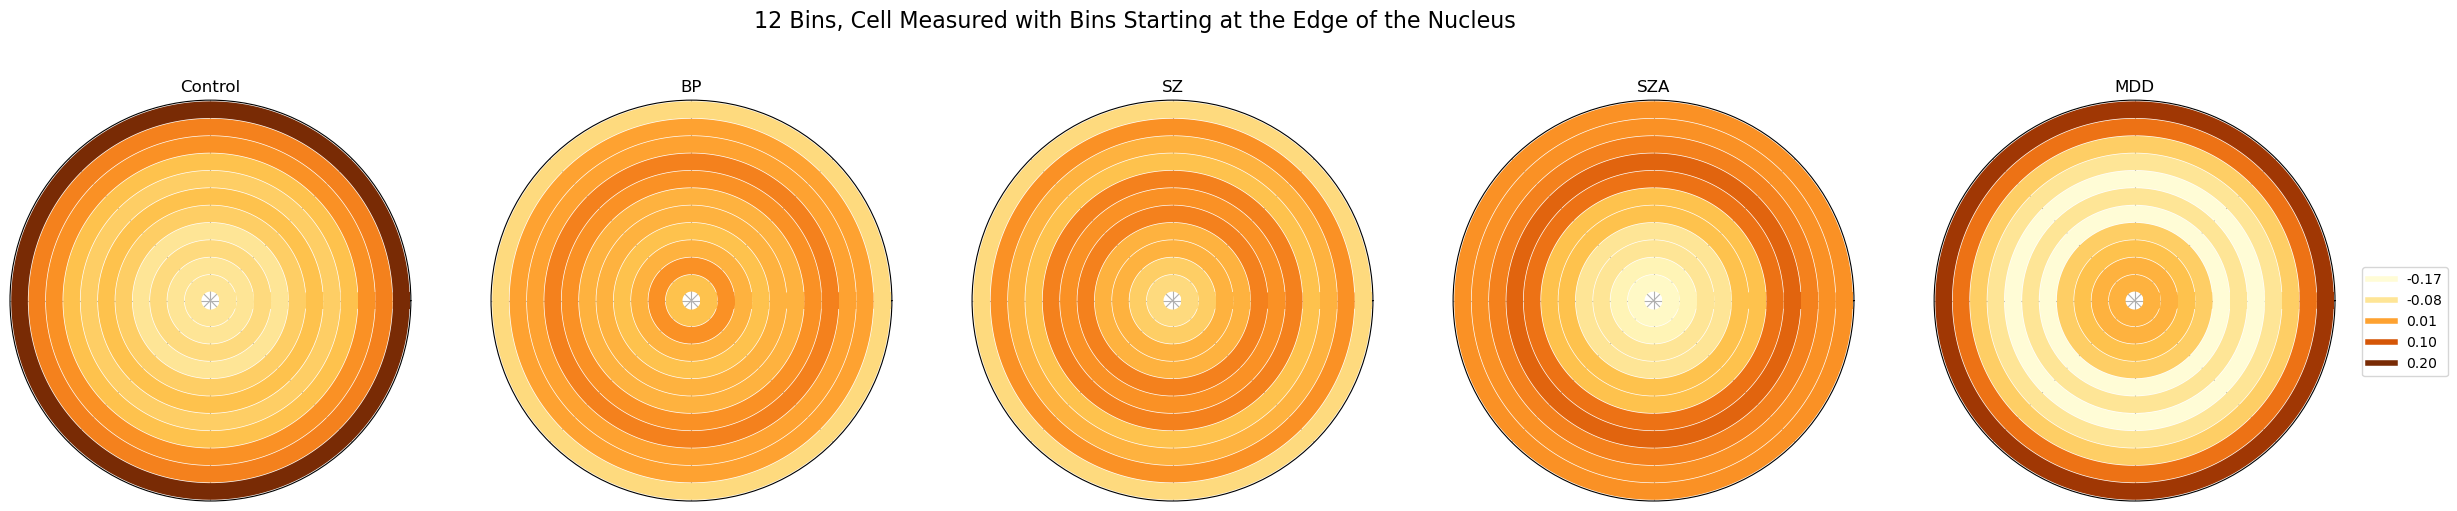

In [18]:
# make custom figure legend
min = df.min().min()
max = df.max().max()
mid = (max+min)/2
legend_elements = [Line2D([0], [0], color=colorlist[0], lw=4, label=f'{min:.2f}'),
                  Line2D([0], [0], color=colorlist[int(vis_bins/4)-1], lw=4, label=f'{(mid+min)/2:.2f}'),
                  Line2D([0], [0], color=colorlist[int(vis_bins/2)-1], lw=4, label=f'{mid:.2f}'),
                  Line2D([0], [0], color=colorlist[int(vis_bins*3/4)-1], lw=4, label=f'{(mid+max)/2:.2f}'),
                  Line2D([0], [0], color=colorlist[vis_bins-1], lw=4, label=f'{max:.2f}')]

# make subplots
fig, ax = plt.subplots(subplot_kw={'projection': 'polar'}, figsize=(6*len(groupdf), 6),nrows=1, ncols=len(groupdf))

for i, label in enumerate(groupdf['label']):
    data = pd.DataFrame({'theta': theta*nbins, 'ringintlist': ringintlist,'ringlist': ringlist})
    g = sns.lineplot(data=data, x='theta', y='ringintlist', hue='ringlist', palette=palette_dict[label], ax=ax[i], linewidth=12)
    g.set(xlabel="")
    g.set(ylabel="")
    g.set(xticklabels=[])
    g.set(yticklabels=[])
    ax[i].set_title(label)
    ax[i].get_legend().remove()
fig.suptitle(f'{nbins} Bins, {nice_text[group]}', fontsize=16)
plt.legend(handles=legend_elements, bbox_to_anchor=(1.05, .6))
# plt.savefig(f'/Users/eweisbar/Documents/projects/MitoDonna/paper/polar_plot_{nbins}_{group}.png', bbox_inches='tight')


# All conditions

-0.1324125873611029 0.1555439344677856
0.0 1.0
-0.1412895167688508 0.1955308141732555
0.0 1.0
-0.1686778182232009 0.1516306949088318
0.0 1.0
-0.149135011096654 0.1532547810001739
0.0 1.0
-0.1163097601597591 0.1313160475296318
0.0 1.0
-0.1030461512084828 0.1183486405187202
0.0 1.0


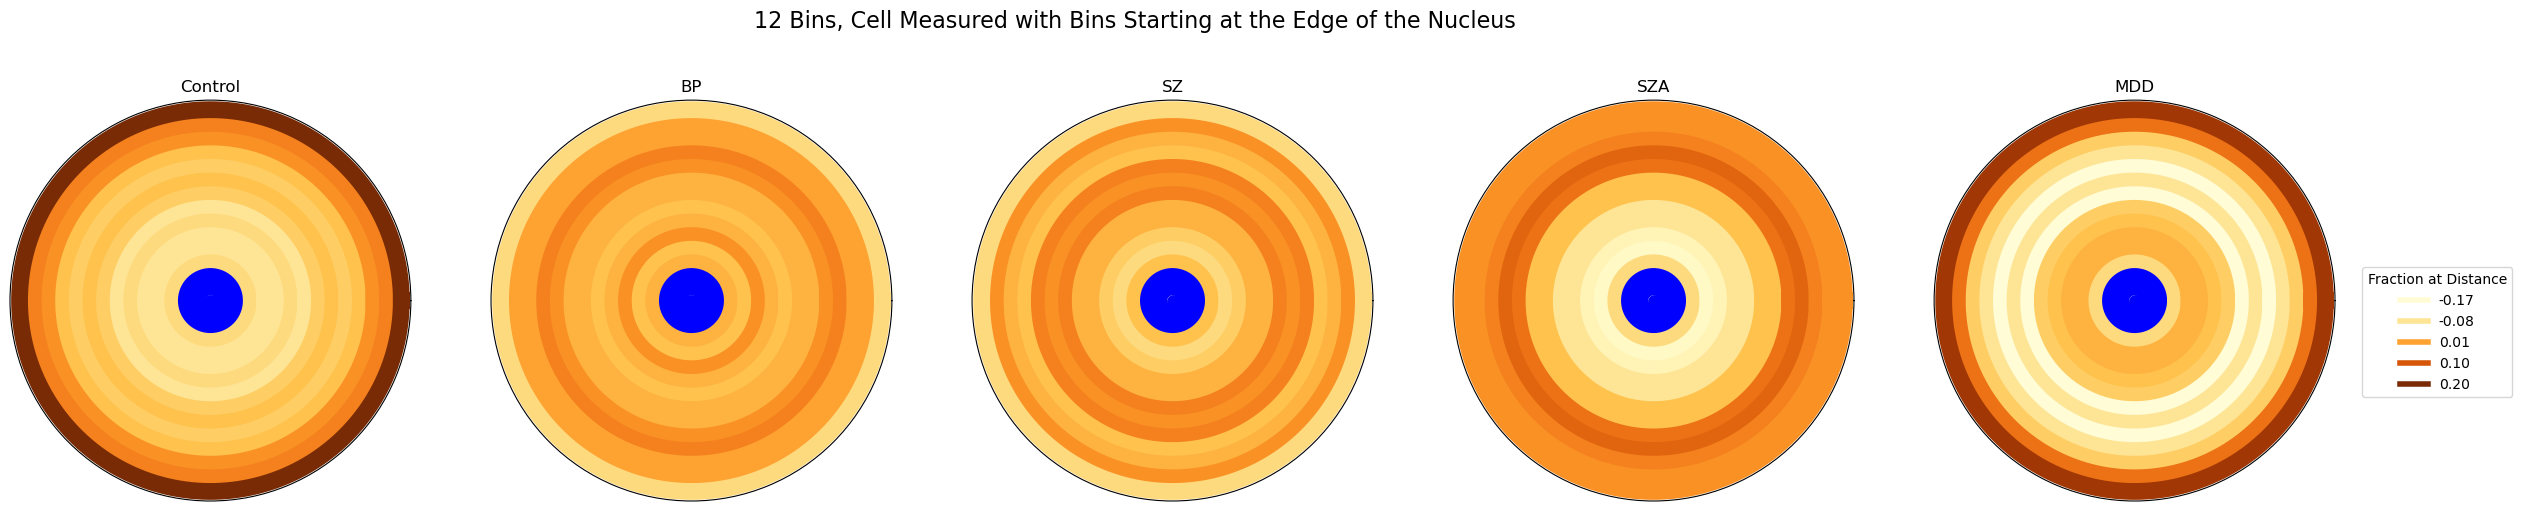

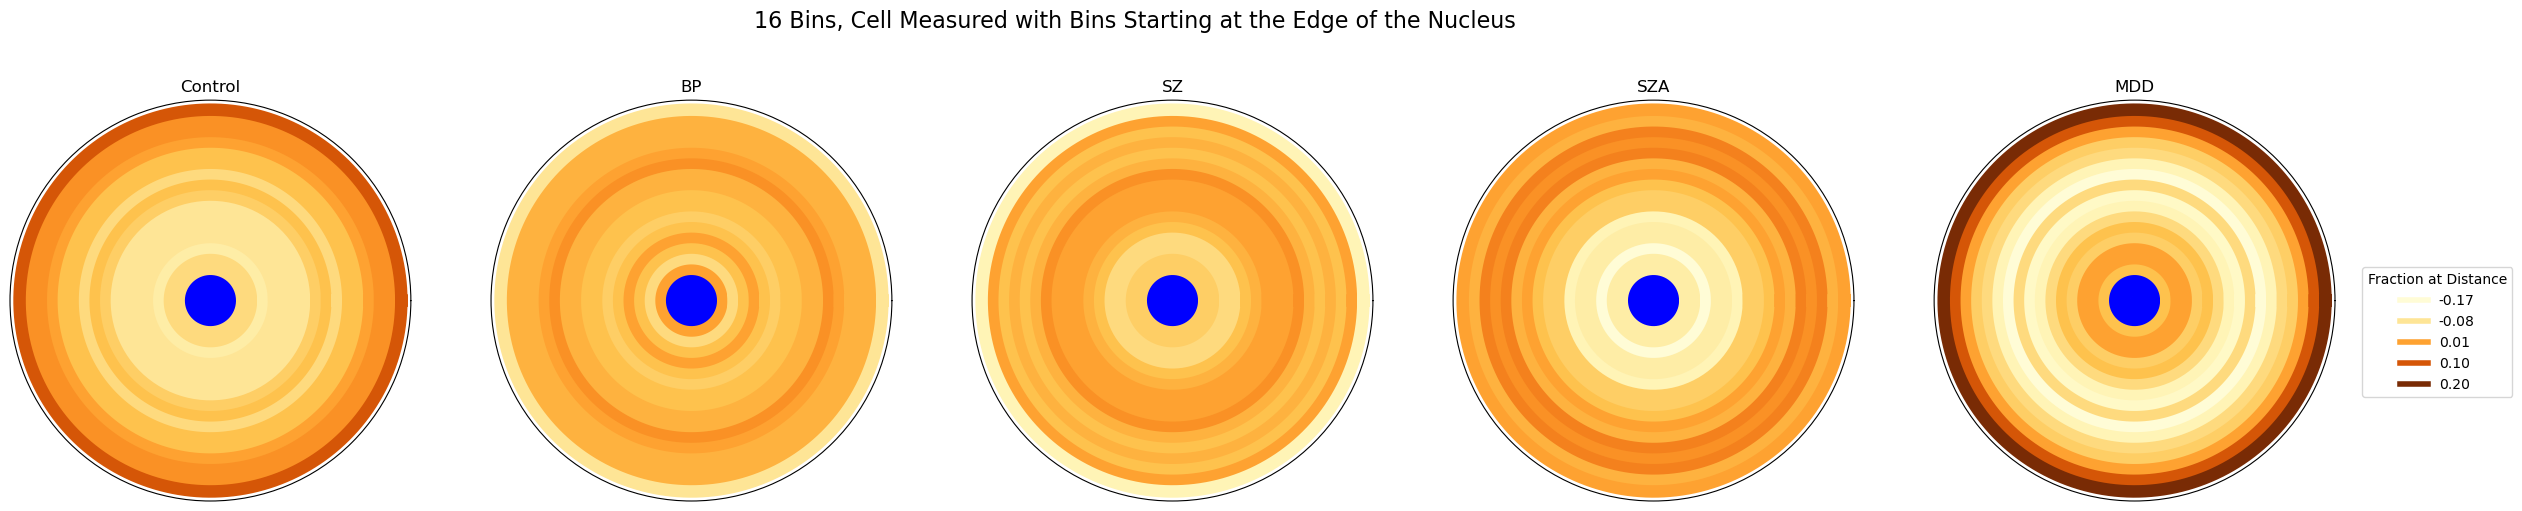

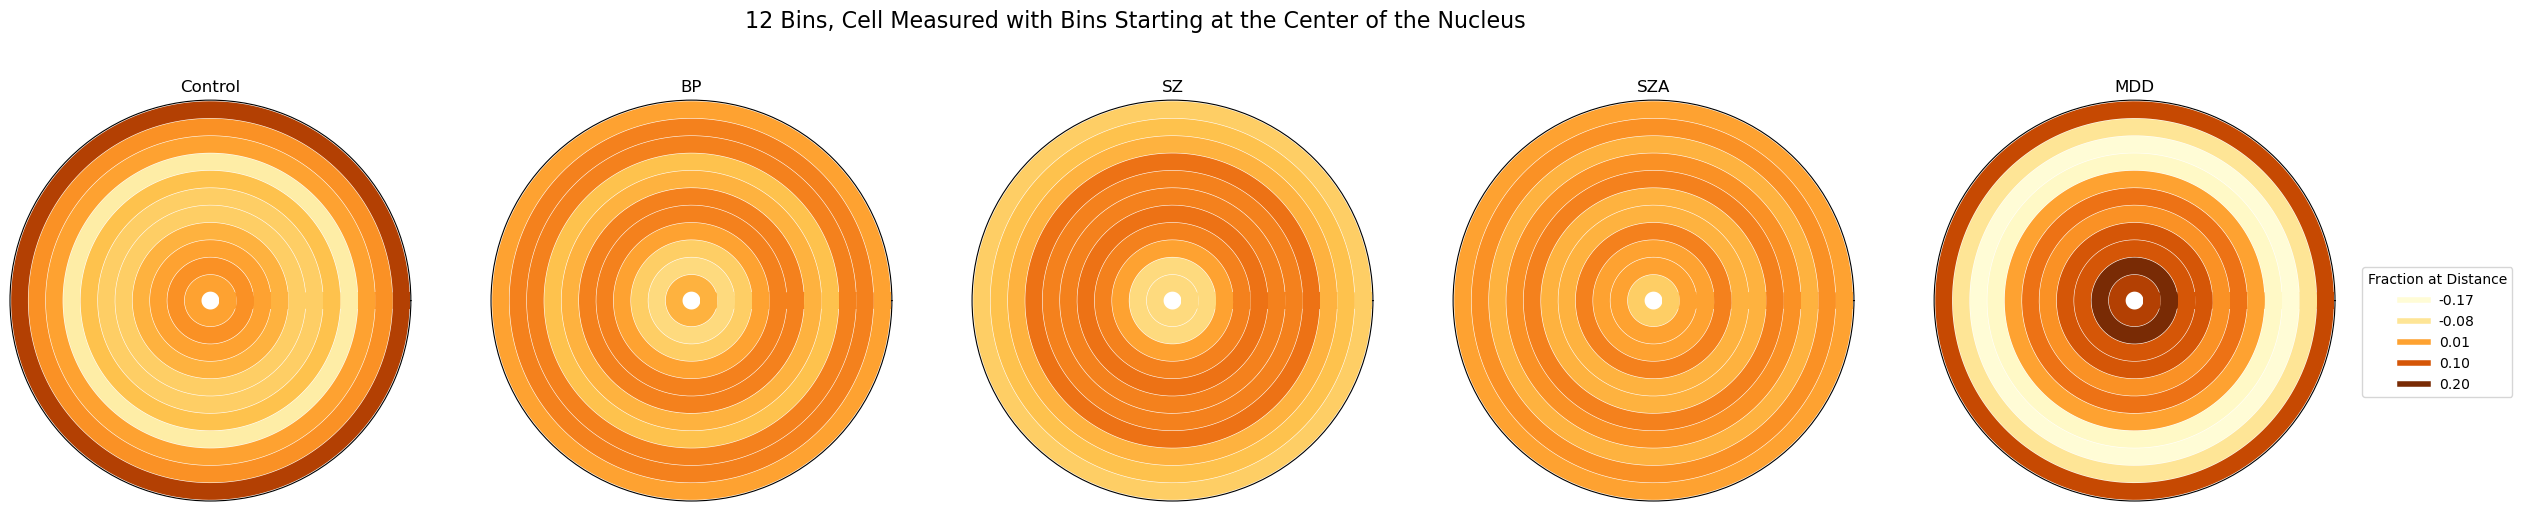

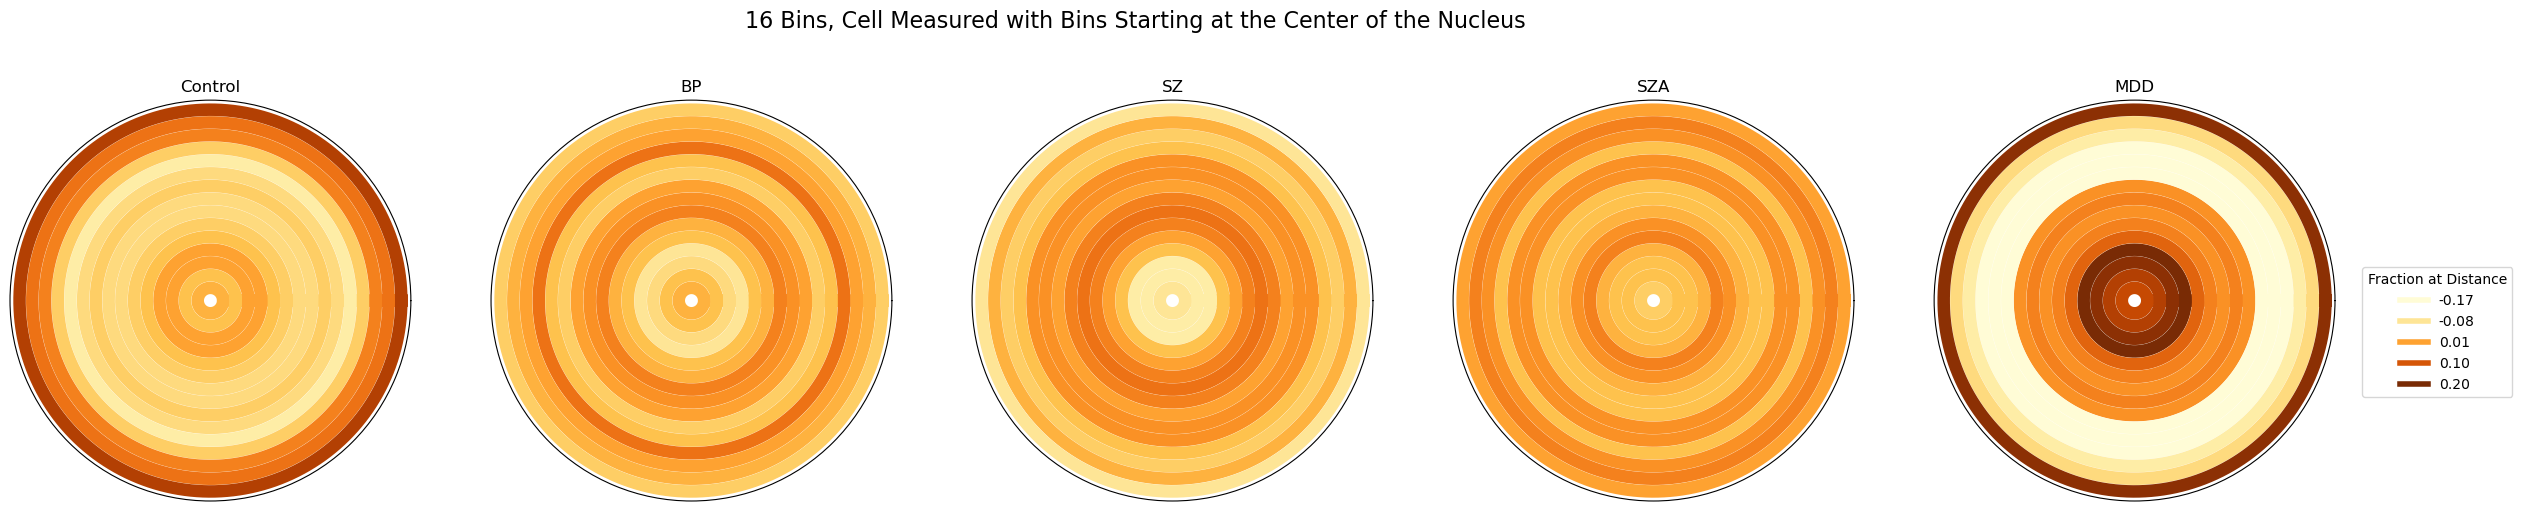

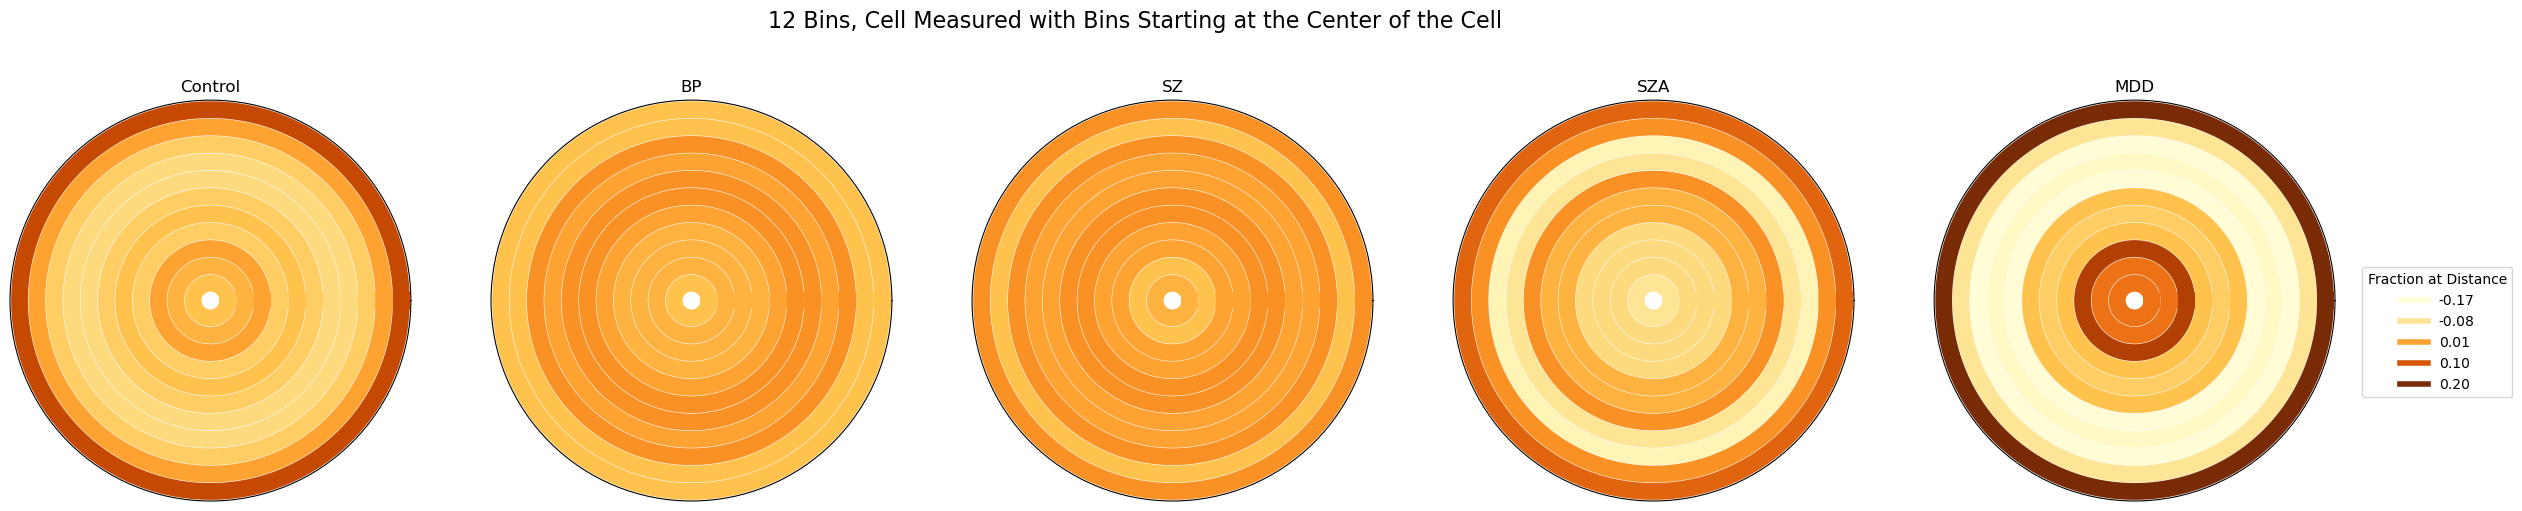

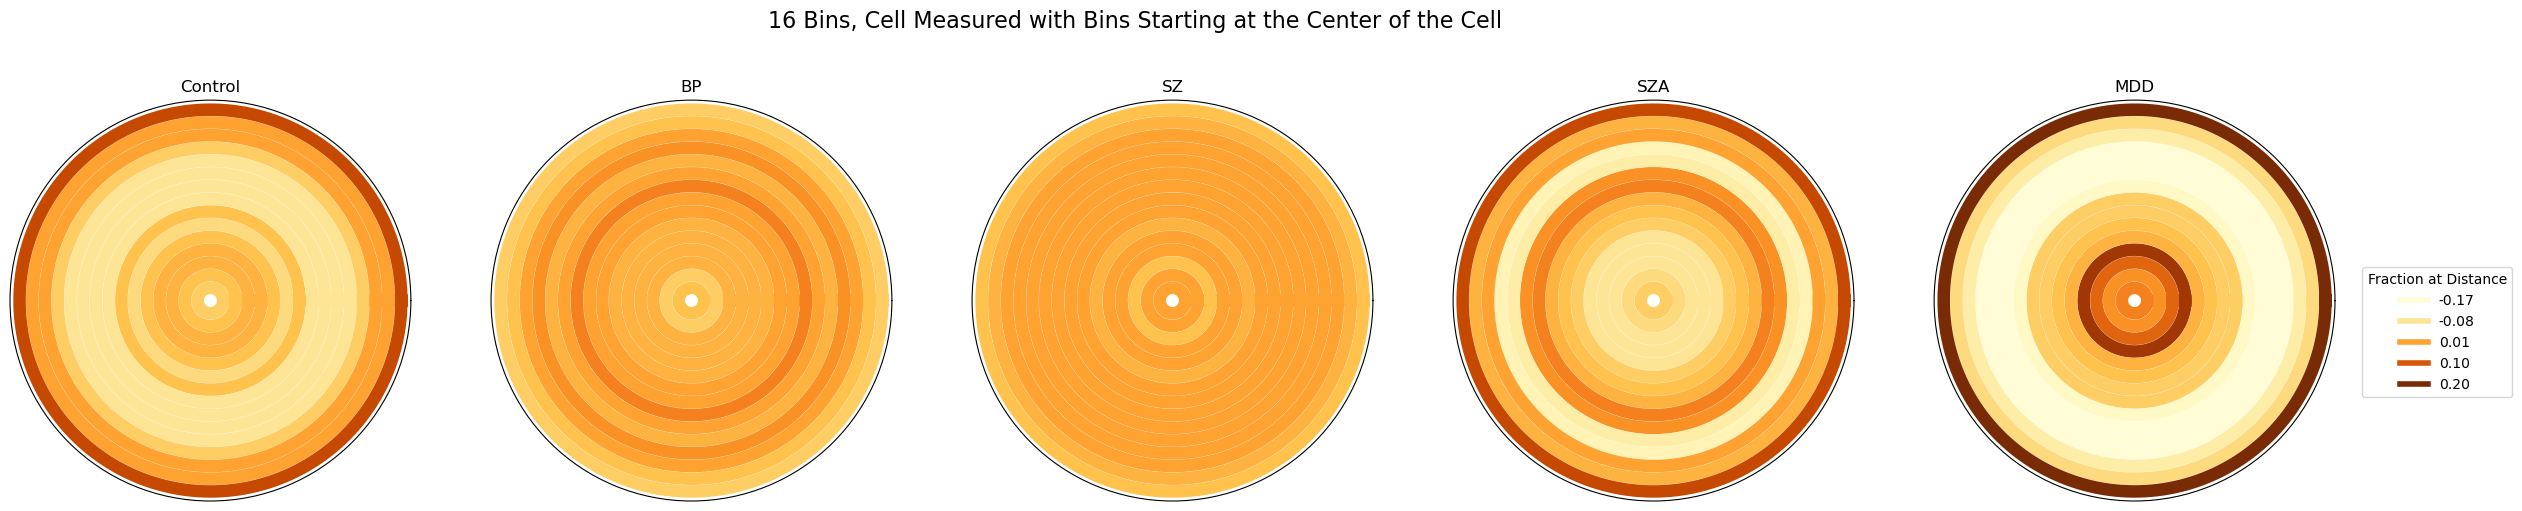

In [7]:
for group in ['CEN','CCN','C']:
    for nbins in [12,16]:
        groupdf = df[[x for x in df.columns if f'of{nbins}' in x and f'_{group}_' in x]]
        groupdf.columns = [x.replace(f'Cells_RadialDistribution_FracAtD_mito_tubeness_{group}_','').replace(f'of{nbins}','') for x in groupdf.columns]

        # min-max rescale data, scale to number of visualization bins to work with visualization strategy
        groupdf = rescale_df(groupdf, vis_bins=vis_bins, castint=True)
        groupdf.reset_index(inplace=True)

        # Bin 1 is missing from CCN. Replace with zeros.
        if group =='CCN':
            groupdf['1'] = 0
        if group == 'CEN':
            # add 3 central rings to illustrate nucleus
            nbins += 3
            groupdf = groupdf.set_index('label')
            groupdf.columns = [str(int(x)+3) for x in groupdf.columns]
            groupdf = groupdf.reset_index()
            groupdf['1']  = groupdf['2'] = groupdf['3'] = 0

        data_dict = {}
        for label in groupdf['label']:
            data_dict[label] = [groupdf.loc[groupdf['label']==label,str(x)].item() for x in range(1,nbins+1)]
        
        # SET UP DATA FOR POLAR PLOTTING
        # Create angles from 0 to 2*pi
        theta = np.linspace(0, 2 * np.pi, 200).tolist()
        ringintlist = []
        ringlist = []
        for bin in range(0, nbins):
            ringintlist += [bin]*len(theta)
            ringlist += [f'ring {bin}']*len(theta)
        colorlist = sns.color_palette("YlOrBr", vis_bins)

        palette_dict = {}
        for label in data_dict.keys():
            palette ={}
            for bin in range(0, nbins):
                palette[f'ring {bin}'] = colorlist[data_dict[label][bin]]
            if group == 'CEN':
                # overwrite for 3 central rings added to signify nucleus
                palette['ring 0'] = palette['ring 1'] = palette['ring 2'] = (0,0,1)    
            palette_dict[label] = palette
        

        # make custom figure legend
        min = df.min().min()
        max = df.max().max()
        mid = (max+min)/2
        legend_elements = [Line2D([0], [0], color=colorlist[0], lw=4, label=f'{min:.2f}'),
                        Line2D([0], [0], color=colorlist[int(vis_bins/4)-1], lw=4, label=f'{(mid+min)/2:.2f}'),
                        Line2D([0], [0], color=colorlist[int(vis_bins/2)-1], lw=4, label=f'{mid:.2f}'),
                        Line2D([0], [0], color=colorlist[int(vis_bins*3/4)-1], lw=4, label=f'{(mid+max)/2:.2f}'),
                        Line2D([0], [0], color=colorlist[vis_bins-1], lw=4, label=f'{max:.2f}')]

        # make subplots
        fig, ax = plt.subplots(subplot_kw={'projection': 'polar'}, figsize=(6*len(groupdf), 6),nrows=1, ncols=len(groupdf))

        nrealbins = nbins
        if group == 'CEN':        
            #return nbins to number counted for labeling purposes
            nbins -= 3
        if nbins == 12:
            linewidth = 12.1
        elif nbins == 16:
            linewidth = 9
        for i, label in enumerate(groupdf['label']):
            data = pd.DataFrame({'theta': theta*nrealbins, 'ringintlist': ringintlist,'ringlist': ringlist})
            g = sns.lineplot(data=data, x='theta', y='ringintlist', hue='ringlist', palette=palette_dict[label], ax=ax[i], linewidth=linewidth)
            if group == 'CEN':
                # fill small empty spot in the middle
                sns.scatterplot(data=[0,0], color='blue', s=100, ax=ax[i])
            g.set(xlabel="",ylabel="",xticklabels=[],yticklabels=[])
            ax[i].set_title(label)
            ax[i].get_legend().remove()
            ax[i].grid(False)
            fig.suptitle(f'{nbins} Bins, {nice_text[group]}', fontsize=16)
        plt.legend(handles=legend_elements, bbox_to_anchor=(1.05, .6),title='Fraction at Distance')
        plt.savefig(f'/Users/eweisbar/Desktop/github/2025_Haghighi_Mito/results/supplemental_fig_radial_dist/FracAtD/polar_plot_{nbins}_{group}.png', bbox_inches='tight')